
<p align='center'> <br> ▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄  </p>
<h2 align="center"> Predicting Fare Amount and Taxi Provider (Refactored) </h2>
<p align="center">its-very-berry-dark</p>
<div>
    <p align="center"> Summary: <br> 
    A personal project restructured from the original file: <i>taxi_prediction_original_2024</i> </b> <br>
</p><br>
</div>

<p align='center'>▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄  </p>

***

#### <span style="color:Orange;">  Table of Contents: </span>

I. Problem Statement and Motivation

II. Data Preparation

III. Exploratory Data Analysis

IV. Feature Importance

V. Model Evaluation

VI. Deep Learning
  
VII. Result and Discussion

VIII. Conclusion and Recommendations

***


<p><br></p>

<h3>  I. Problem Statement and Motivation </h3>

For a big dataset, particularly with tens of millions of rows, there is inevitability that the data input would have issues whether it's redundant entries, impossible-in-real-life values, etc. This project intends to explore more about the cleaning stage, then perform brief EDA. After the analysis, I'll be proceeding to feature importance stage, then training machine learning and deep learning models. Furthermore, same with the motivation of the original project, I intend to enhance the efficiency and accuracy of fare prediction in this project. This is essentially important since having robust predictive models can streamline operational processes and become a guide for passengers in budgeting their trips, etc. Overall, by leveraging machine learning and deep learning techniques, this project aims to address real-world challenges in the taxi industry.
<p><br><br></p>

***

Importing Modules and Initiliazing a Class

In [78]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow import keras

from datetime import datetime
from datetime import timedelta

plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', 40)   # displays max columns of the DataFrame 
color_pal = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
# for print content visualizations
class colors:
    GREEN = '\033[92m'
    RED = '\033[91m'
    END = '\033[0m'


## <span style="color:Orange;"> IV. Data Preparation </span>


For faster handling of the million rows of data, the chunking method is utilized. The provider categories (`Provider Name`) with less than 100k trip records are removed (five taxi providers specifically) as they were deemed insufficient for running the models. At the end, the filtered data in the list are concatenated together and transformed into a DataFrame format.

In [3]:
# Filtering out rows not included in the provider_counts list
path = "../data/taxi_final.csv"       # replace the path if the taxi_final.csv is in another folder

data_chunks = []
chunksize = 500000       # Specify chunksize (number of rows to read at a time)

print("Scanning for major taxi providers...")
provider_counts = pd.Series(dtype='int')

# Read ONLY the ProviderName column in chunks to save memory
for chunk in pd.read_csv(path, chunksize=chunksize, usecols=['PROVIDER NAME']):
    # Tally up the counts and add them to our running total
    provider_counts = provider_counts.add(chunk['PROVIDER NAME'].value_counts(), fill_value=0)

# Keeping only providers with more than 100,000 rides
valid_providers = provider_counts[provider_counts > 150000].index.tolist()
print(f"Keeping {len(valid_providers)} major providers out of {len(provider_counts)} total.")

Scanning for major taxi providers...
Keeping 9 major providers out of 14 total.


In [4]:
print("\nProcessing and sampling the full dataset...")
sampled_chunks = []

for chunk in pd.read_csv(path, chunksize=chunksize, low_memory=False):
    
    # Filter out the rare providers 
    filtered_chunk = chunk[chunk['PROVIDER NAME'].isin(valid_providers)]
    
    # Take a random 50% sample of the surviving rows
    sample = filtered_chunk.sample(frac=0.5, random_state=42)
    
    sampled_chunks.append(sample)

# Finally, glue all the tiny 5% chunks together into one master DataFrame
initial_df = pd.concat(sampled_chunks, ignore_index=True)

print(f"\nSuccess! Final sampled dataset size: " + colors.GREEN + f"{len(initial_df)} " + colors.END + "rows.")


Processing and sampling the full dataset...

Success! Final sampled dataset size: 5890155 rows.


Because this project involved multi-task learning (predicting both continuous Fare Price and categorical Provider Name), I implemented class balancing via under-sampling. This prevented the classifier from defaulting to the majority class (e.g. CMT), ensuring the neural network learned the true distinct feature profiles of minority providers.

In [5]:
#renaming the column with an inconsistent structure for better reading
initial_df.rename(columns={'PROVIDER NAME': 'ProviderName', 'Milage': 'Mileage'}, inplace=True)  

In [6]:
initial_df.head(2)

,Type,ProviderName,StartDateTime,DateCreated,ID,ExternalID,FareAmount,GratuityAmount,SurchargeAmount,ExtraFareAmount,TollAmount,TotalAmount,PaymentType,StartDateTime.1,EndDateTime,OriginStreetNumber,OriginStreetName,OriginCity,OriginState,OriginZip,OriginLatitude,OriginLongitude,DestinationStreetNumber,DestinationStreetName,DestinationCity,DestinationState,DestinationZip,DestinationLatitude,DestinationLongitude,Mileage,Duration,Unnamed: 31
0,1.0,CMT,2017-12-22 22:57:29.4600000 +00:00,2017-12-23 21:30:08.8733333 +00:00,A188__61272__2017-12-23T21:30:08.873_36370745,36370745,11.35,3.15,0.25,1.00,0.0,15.75,1.0,2017-12-22 22:57:29.4600000 +00:00,2017-12-22 23:08:52.8100000 +00:00,NaN,1600 Nw I St,Washington,DC,20006,38.90130,-77.03681,NaN,3620 Nw 16th St,Washington,DC,20010,38.93572,-77.03645,3.00,11.0,NaN
1,5.0,Yellow Cab,2017-12-14 07:09:36.0000000 +00:00,2017-12-14 08:02:50.1533333 +00:00,G671__77581__2017-12-14T08:02:50.153_36324214,36324214,25.12,0.00,0.25,3.25,0.0,48.62,2.0,2017-12-14 07:09:36.0000000 +00:00,2017-12-14 08:02:49.0000000 +00:00,NaN,"820 CHESAPEAKE STREET SOUTHEAST , WASHINGTON, ...",NaN,NaN,20032,38.82938,-76.99247,NaN,"2412 FRANKLIN STREET NORTHEAST, WASHINGTON, 20018",NaN,NaN,20018,38.92621,-76.97138,12.03,53.0,NaN


### Duplicate Data 
Compared to the Unique IDs present on the original project, the current work has no duplicated instances of taxi trips.

In [6]:
# counts the number of duplicated rows
print(f"Number of duplicated unique IDs: " + colors.GREEN + f"{initial_df.duplicated(subset=['ID']).sum()}" + colors.END)

Number of duplicated unique IDs: 13


In [8]:
initial_df.loc[initial_df.duplicated(subset=['ID'])]   

,Type,ProviderName,StartDateTime,DateCreated,ID,ExternalID,FareAmount,GratuityAmount,SurchargeAmount,ExtraFareAmount,TollAmount,TotalAmount,PaymentType,StartDateTime.1,EndDateTime,OriginStreetNumber,OriginStreetName,OriginCity,OriginState,OriginZip,OriginLatitude,OriginLongitude,DestinationStreetNumber,DestinationStreetName,DestinationCity,DestinationState,DestinationZip,DestinationLatitude,DestinationLongitude,Mileage,Duration,Unnamed: 31
2106218,1,UVC,2017-02-01 00:00:00.0000000 +00:00,2017-02-01 00:16:43.7633333 +00:00,G836__74262__2017-02-01T00:16:43.763_27245853,27245853,6.22,1.00,0.25,0.00,0.0,7.47,1.0,2017-02-01 00:00:00.0000000 +00:00,2017-02-01 00:06:00.0000000 +00:00,NaN,515 15th St Nw,Washington,DC,20004,38.89709,-77.03318,NaN,1201-1207 13th St NW,Washington,DC,20005,38.90588,-77.02958,0.80,6.0,NaN
4413030,1,Transco,2017-06-01 00:00:00.0000000 +00:00,2017-06-02 08:50:36.8200000 +00:00,K805__52078__2017-06-02T08:50:36.820_32169901,32169901,14.32,3.51,0.25,3.00,0.0,21.08,1.0,2017-06-01 00:00:00.0000000 +00:00,2017-06-01 00:12:00.0000000 +00:00,NaN,S Smith Blvd Arlington,NaN,VA,22202.0,38.85187,-77.04321,NaN,1357 16th St Nw,Washington,DC,20036.0,38.90817,-77.03640,4.68,12.0,NaN
4705713,1,Transco,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 15:25:12.3366667 +00:00,M130__91165__2017-07-01T15:25:12.337_33198163,33198163,11.62,0.00,0.25,2.00,0.0,13.87,2.0,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 00:14:00.0000000 +00:00,NaN,4909 7th St Nw,Washington,DC,20011,38.94997,-77.02198,NaN,1181 U St Nw,Washington,DC,20009,38.91709,-77.02786,2.64,14.0,NaN
4719325,1,VeriFone,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 16:02:22.1800000 +00:00,F997__91192__2017-07-01T16:02:22.180_33199349,33199349,7.57,0.00,0.25,0.00,0.0,7.82,2.0,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 00:08:00.0000000 +00:00,NaN,3804 Georgia Ave Nw [Us-29],Washington,DC,20011,38.93764,-77.02455,NaN,1876 Wiltberger St Nw,Washington,DC,20001,38.91523,-77.02092,1.56,8.0,NaN
4793721,1,UVC,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 00:21:34.9233333 +00:00,E357__71929__2017-07-01T00:21:34.923_33184084,33184084,7.57,0.00,0.25,0.00,0.0,7.82,2.0,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 00:06:00.0000000 +00:00,NaN,4301 Military Rd NW,Washington,MD,20015,38.96111,-77.08509,NaN,7315 WAVERLY ST,Bethesda,MD,20814,38.98289,-77.09313,1.60,6.0,NaN
4808461,1,Transco,2017-10-01 00:00:00.0000000 +00:00,2017-10-01 16:26:35.4400000 +00:00,K788__77769__2017-10-01T16:26:35.440_35424846,35424846,10.27,0.00,0.25,0.00,0.0,10.52,2.0,2017-10-01 00:00:00.0000000 +00:00,2017-10-01 00:14:00.0000000 +00:00,NaN,1984 Vermont Ave Nw,Washington,DC,20001,38.91667,-77.02561,NaN,1211 Wisconsin Ave Nw,Washington,DC,20007,38.90546,-77.06281,2.59,14.0,NaN
4818157,1,VeriFone,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 15:32:17.4166667 +00:00,D790__76939__2017-07-01T15:32:17.417_33198525,33198525,12.16,0.00,0.25,3.00,0.0,15.41,1.0,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 00:09:00.0000000 +00:00,NaN,S Smith Blvd Arlington,NaN,VA,22202,38.85232,-77.04338,NaN,2242 I St Nw,Washington,DC,20037,38.90061,-77.04940,3.90,9.0,NaN
4915567,1,Transco,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 16:36:04.9733333 +00:00,D391__77123__2017-07-01T16:36:04.973_33200319,33200319,18.64,5.41,0.25,2.75,0.0,27.05,1.0,2017-07-01 00:00:00.0000000 +00:00,2017-07-01 00:22:00.0000000 +00:00,NaN,Washington,NaN,VA,20001,38.85628,-77.04432,NaN,3377 16th St Nw,Washington,DC,20010,38.93301,-77.03642,5.70,22.0,NaN
5332146,1,DC VIP Cab,2017-04-01 00:00:00.0000000 +00:00,2017-04-02 18:35:58.5200000 +00:00,G494__61405__2017-04-02T18:35:58.520_29839544,29839544,11.08,1.23,0.25,1.00,0.0,13.56,1.0,2017-04-01 00:00:00.0000000 +00:00,2017-04-01 00:16:38.0000000 +00:00,NaN,822 E STREET NW WASHINGTON,WASHINGTON,DC,20004,38.89610,-77.02310,NaN,1231 25th Street Northwest,Washington,DC,20037,38.90680,-77.05320,2.20,17.0,NaN
5362415,1,Transco,2017-04-01 00:00:00.0000000 +00:00,2017-04-02 16:54:58.7200000 +00:00,E986__79570__2017-04

In [7]:
initial_df = initial_df.loc[~initial_df.duplicated(subset=['ID'])].reset_index(drop=True).copy()
print(f"Number of duplicated rows after changes: " + colors.GREEN + f"{initial_df.duplicated(subset=['ID']).sum()}" + colors.END)

Number of duplicated rows after changes: 0


### Null Values and Imputation 
<span style="font-size:larger;"> Both <i> StartDateTime </i> and <i> StartDateTime.1 </i> columns are the same, will remove the 2nd occurrence </span>  
<i> New changes: The duplicated column will not be utilized and the EndDateTime will be removed since there's already a `Duration` column. </i>  
    The DataFrame example below only displays the similarities of the mentioned column as an insight.

In [8]:
df = initial_df.copy()

In [11]:
df[['StartDateTime', 'PaymentType', 'StartDateTime.1', 'EndDateTime']].head(2)

,StartDateTime,PaymentType,StartDateTime.1,EndDateTime
0,2017-12-22 22:57:29.4600000 +00:00,1.0,2017-12-22 22:57:29.4600000 +00:00,2017-12-22 23:08:52.8100000 +00:00
1,2017-12-14 07:09:36.0000000 +00:00,2.0,2017-12-14 07:09:36.0000000 +00:00,2017-12-14 08:02:49.0000000 +00:00


***
 #### Imputation and Null Values
<span style="font-size:larger;"> Duration </span>   
In this dataset, we focused on identifying columns that might be a duplicate of another and determining each of the columns' null value. Since Duration has almost 18k null rows, I've imputed it based on the difference of `StartDateTime` and `EndDateTime` columns. The units used for the mentioned column is in minutes, which is retained.

In [9]:
df['Duration'].isnull().sum()

np.int64(179708)

In [10]:
df['StartDateTime'] = pd.to_datetime(df['StartDateTime'])
df['EndDateTime'] = pd.to_datetime(df['EndDateTime'])

missing_mask = df['Duration'].isna()
# imputing missing values on Duration column 
df.loc[missing_mask, 'Duration'] = (
    df['EndDateTime'] - df['StartDateTime']
).dt.total_seconds() / 60

<span style="font-size:larger;"> Date and Location </span>   

In [11]:
# Converting the datetime-like string column to datetime
# Coerce sets the out of bounds date format of observation into NaT (Non-parseable dates)
# ONLY RUN THIS CELL ONCE
df['StartDateTime'] = pd.to_datetime(df['StartDateTime'], utc=True, errors='coerce')

In [12]:
# Extracting date and time into separate columns
df['Pickup_Hour'] = df['StartDateTime'].dt.hour
df['Pickup_DayoftheWeek'] = df['StartDateTime'].dt.dayofweek

# Changing column dtypes
df['ProviderName'] = df['ProviderName'].astype('category')      # setting ProviderName as a category dtype

For more granularity, the `Pickup_Hour` and `Pickup_DayoftheWeek` is created to observe more insightful patterns. Dropping the listed columns below as they would only create more noise in the dataset (and for efficiency). Will only be using the coordinates columns (`OriginLatitude`, `OriginLongitude`, `'DestinationLatitude`, `DestinationLongitude`) for location. Unique Identifiers will be dropped as well.

In [16]:
df.columns

Index(['Type', 'ProviderName', 'StartDateTime', 'DateCreated', 'ID',
       'ExternalID', 'FareAmount', 'GratuityAmount', 'SurchargeAmount',
       'ExtraFareAmount', 'TollAmount', 'TotalAmount', 'PaymentType',
       'StartDateTime.1', 'EndDateTime', 'OriginStreetNumber',
       'OriginStreetName', 'OriginCity', 'OriginState', 'OriginZip',
       'OriginLatitude', 'OriginLongitude', 'DestinationStreetNumber',
       'DestinationStreetName', 'DestinationCity', 'DestinationState',
       'DestinationZip', 'DestinationLatitude', 'DestinationLongitude',
       'Mileage', 'Duration', 'Unnamed: 31', 'Pickup_Hour',
       'Pickup_DayoftheWeek'],
      dtype='str')

In [13]:
columns_to_drop = [
    'StartDateTime', 'StartDateTime.1', 
    'DateCreated', 'EndDateTime', 
    'OriginStreetNumber', 'DestinationStreetNumber', 
    'OriginStreetName', 'DestinationStreetName',
    'OriginCity', 'DestinationCity',
    'OriginState', 'DestinationState',
    'OriginZip', 'DestinationZip', 'Unnamed: 31',
    'Type', 'ID', 'ExternalID', 'PaymentType'
]

actual_cols_to_drop = [col for col in columns_to_drop if col in df.columns]
print(f"Dropping {len(actual_cols_to_drop)} useless or leaky columns...")
df = df.drop(columns=actual_cols_to_drop)
print(f"Remaining Columns: \n {df.columns}")

Dropping 19 useless or leaky columns...
Remaining Columns: 
 Index(['ProviderName', 'FareAmount', 'GratuityAmount', 'SurchargeAmount',
       'ExtraFareAmount', 'TollAmount', 'TotalAmount', 'OriginLatitude',
       'OriginLongitude', 'DestinationLatitude', 'DestinationLongitude',
       'Mileage', 'Duration', 'Pickup_Hour', 'Pickup_DayoftheWeek'],
      dtype='str')


Since there are many columns with null values, it is necessary to drop indexes with null values for a cleaner data. For columns representing transactions and location, the null rows will be dropped.

In [14]:
df.dropna(subset=['GratuityAmount', 'SurchargeAmount', 'ExtraFareAmount', 'TollAmount',
                  'OriginLatitude', 'OriginLongitude', 'DestinationLatitude',
                  'DestinationLongitude', 'Mileage'], inplace=True)

In [15]:
df.isnull().sum()

ProviderName            0
FareAmount              0
GratuityAmount          0
SurchargeAmount         0
ExtraFareAmount         0
TollAmount              0
TotalAmount             0
OriginLatitude          0
OriginLongitude         0
DestinationLatitude     0
DestinationLongitude    0
Mileage                 0
Duration                0
Pickup_Hour             0
Pickup_DayoftheWeek     0
dtype: int64

### Removing rows that have a negative value on numerical columns (FareAmount, Mileage, Duration)
There are some inconsistent rows that had a negative value for the numerical dtypes column. For more accurate representation of data, the group opted to transform the negative values into positive values, since there might be some error on inputting the data which turned the input values into negative. Additionally, any inconsistent rows will be deleted as well, such as:
- Other numerical values that has 0.0 values
- The <span style="color:blue;"> Duration </span> of a taxi ride being 0.0 but the <span style="color:blue;"> FareAmount </span> is more than <span style="color:blue;"> 0 </span>
- <span style="color:red;"> Mileage </span> that doesn't seem to fit the values with <span style="color:red;"> Duration </span> and <span style="color:red;"> FareAmount </span>, etc.

#### Negative and Zero Values

In [20]:
df.describe()

,FareAmount,GratuityAmount,SurchargeAmount,ExtraFareAmount,TollAmount,TotalAmount,OriginLatitude,OriginLongitude,DestinationLatitude,DestinationLongitude,Mileage,Duration,Pickup_Hour,Pickup_DayoftheWeek
count,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06,5.835174e+06
mean,1.269852e+01,1.425035e+00,2.487456e-01,6.017132e-01,4.167542e-03,1.507104e+01,3.767141e+01,-7.460700e+01,3.772761e+01,-7.470977e+01,1.536344e+01,7.959284e+02,1.391229e+01,2.819220e+00
std,1.959599e+02,1.122887e+02,9.341773e-02,1.155478e+00,1.362913e+00,2.264633e+02,6.844999e+00,1.345570e+01,6.662063e+00,1.319767e+01,2.812138e+02,1.261438e+05,5.842859e+00,1.851835e+00
min,-1.673500e+02,-4.640000e+00,-9.950000e+01,-5.390000e+02,-1.500000e+00,-5.325300e+02,-7.731294e+01,-7.770300e+02,0.000000e+00,-7.770300e+02,-3.320000e+01,-1.435000e+03,0.000000e+00,0.000000e+00
25%,7.300000e+00,0.000000e+00,2.500000e-01,0.000000e+00,0.000000e+00,8.900000e+00,3.889341e+01,-7.704335e+01,3.889215e+01,-7.704550e+01,1.000000e+00,8.000000e+00,1.000000e+01,1.000000e+00
50%,1.009000e+01,0.000000e+00,2.500000e-01,0.000000e+00,0.000000e+00,1.198000e+01,3.890016e+01,-7.703199e+01,3.890132e+01,-7.703240e+01,2.000000e+00,1.300000e+01,1.500000e+01,3.000000e+00
75%,1.459000e+01,2.000000e+00,2.500000e-01,1.000000e+00,0.000000e+00,1.734000e+01,3.890663e+01,-7.701940e+01,3.891130e+01,-7.701750e+01,3.720000e+00,2.600000e+01,1.800000e+01,4.000000e+00
max,3.489662e+05,1.525250e+05,2.189000e+01,6.960000e+02,3.014000e+03,3.489810e+05,3.006980e+02,1.651319e+02,3.006980e+02,1.651319e+02,4.105985e+05,2.522689e+07,2.300000e+01,6.000000e+00


In [21]:
df.columns

Index(['ProviderName', 'FareAmount', 'GratuityAmount', 'SurchargeAmount',
       'ExtraFareAmount', 'TollAmount', 'TotalAmount', 'OriginLatitude',
       'OriginLongitude', 'DestinationLatitude', 'DestinationLongitude',
       'Mileage', 'Duration', 'Pickup_Hour', 'Pickup_DayoftheWeek'],
      dtype='str')

In [16]:
print(f"Number of rows that has a negative values in Duration Column:    " + colors.GREEN + f"{df.query('Duration < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in Mileage Column:    " + colors.GREEN + f"{df.query('Mileage < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in FareAmount Column: " + colors.GREEN + f"{df.query('FareAmount < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in GratuityAmount Column:    " + colors.GREEN + f"{df.query('GratuityAmount < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in SurchargeAmount Column:    " + colors.GREEN + f"{df.query('SurchargeAmount < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in ExtraFareAmount Column: " + colors.GREEN + f"{df.query('ExtraFareAmount < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in TollAmount Column:    " + colors.GREEN + f"{df.query('TollAmount < 0.0').shape[0]}" + colors.END)
print(f"Number of rows that has a negative values in TotalAmount Column:    " + colors.GREEN + f"{df.query('TotalAmount < 0.0').shape[0]}" + colors.END)


Number of rows that has a negative values in Duration Column:    26
Number of rows that has a negative values in Mileage Column:    255
Number of rows that has a negative values in FareAmount Column: 1563
Number of rows that has a negative values in GratuityAmount Column:    46
Number of rows that has a negative values in SurchargeAmount Column:    1277
Number of rows that has a negative values in ExtraFareAmount Column: 5380
Number of rows that has a negative values in TollAmount Column:    3
Number of rows that has a negative values in TotalAmount Column:    1567


Since there are only few rows in some columns that had negative values, it will be dropped from the dataset.

In [17]:
df = df[
    (df['FareAmount'] > 0) & 
    (df['Mileage'] > 0) & 
    (df['Duration'] > 0) &
    (df['GratuityAmount'] >= 0) & 
    (df['SurchargeAmount'] >= 0) & 
    (df['ExtraFareAmount'] >= 0) &
    (df['TollAmount'] >= 0) & 
    (df['TotalAmount'] > 0) 
]

print(f"Cleanup complete. Rows remaining: {len(df)}")

Cleanup complete. Rows remaining: 5430237


#### Inconsistent Columns and Extreme Values
In this section, the data will be filtered depending on the set domain constrained filtering. The set conditions are only an estimation to <i> remove the rows with extreme inconsistent column </i> against the other interdependent columns. I created two temporary columns that would measure MPH and Fare per Mile. This project will only KEEP rows that pass both physical and financial realities (if ever there is inconsistent rows).
1. The speed must be less than or equal to 70 mph.
2. The fare per mile must be less than or equal to $4.00 [1].

[1] https://latestcost.com/average-taxi-cost-united-states/

In [ ]:
# Speed = Distance / Time (converted from minutes to hours)
df['Calculated_MPH'] = df['Mileage'] / (df['Duration'] / 60)

# Calculate the Fare per Mile
df['Calculated_FarePerMile'] = df['FareAmount'] / df['Mileage']

# Multivariate Filter
df_clean = df[
    # Ceiling: The maximum speed limit 
    (df['Calculated_MPH'] <= 70) & 
    # The very maximum value for base fare [1]
    (df['Calculated_FarePerMile'] <= 4.00) &

    # The Floors (Too Cheap - Catches the 1000 miles for $14 glitch)
    (df['Calculated_FarePerMile'] >= 1.00) & 
    # The Absolute Physical Cap (Too Far)
    (df['Mileage'] <= 150)
]

In [19]:
# Drop the temporary calculation columns to keep the dataset tidy
df_clean = df_clean.drop(columns=['Calculated_MPH', 'Calculated_FarePerMile'])

print(f"Cleaned rows: {len(df_clean)}")
print(f"Anomalies removed: {len(df) - len(df_clean)}")

Cleaned rows: 1643059
Anomalies removed: 3787178


Class-Imbalance Check

As seen in the content below, there is a class imbalance on the taxi provider column, `Provider Name`. I intend to balance it off into 30k rows per provider as the distribution is skewed. The threshold is set according to the provider with the lowest value (Grand Cab) to balance out the dataset. The threshold is set to maximize the model's accuracy on the top 9 providers that control 90% of the city's market share, prioritizing business impact over minor edge cases

In [20]:
print(f"Number of Taxi Providers: \n\n{df_clean['ProviderName'].value_counts()}")

Number of Taxi Providers: 

ProviderName
CMT           290683
UVC           289101
Yellow Cab    253509
DC VIP Cab    212028
Transco       207960
Hitch         151005
VeriFone      145650
Bay Cab        62145
Grand Cab      30978
Name: count, dtype: int64


In [21]:
target_providers = [
    'CMT', 'UVC', 'Hitch', 'DC VIP Cab', 'Transco', 
    'VeriFone', 'Yellow Cab', 'Bay Cab', 'Grand Cab'
]

# Filtering the dataframe to only include the 8 major providers
df_clean = df_clean[df_clean['ProviderName'].isin(target_providers)]

# Under-sample the majority classes to exactly 30,000 rows each
df_balanced = df_clean.groupby('ProviderName').sample(n=30000, random_state=42)

print("\n--- CLASS BALANCING COMPLETE ---")
print(f"Total rows in balanced dataset: " + colors.GREEN + f"{len(df_balanced)}" + colors.END)
print("\nNew Provider Distribution:")
print(df_balanced['ProviderName'].value_counts())


--- CLASS BALANCING COMPLETE ---
Total rows in balanced dataset: 270000

New Provider Distribution:
ProviderName
Bay Cab       30000
CMT           30000
DC VIP Cab    30000
Grand Cab     30000
Hitch         30000
Transco       30000
UVC           30000
VeriFone      30000
Yellow Cab    30000
Name: count, dtype: int64



## <span style="color: Orange;"> III. Exploratory Data Analysis (EDA) </span>

This section focuses more in exploring the cleaned dataset univariately and multivariately. The dataset has some of observations remove due to outliers.

#### Univariate Analysis

In [38]:
df_balanced.columns

Index(['ProviderName', 'FareAmount', 'GratuityAmount', 'SurchargeAmount',
       'ExtraFareAmount', 'TollAmount', 'TotalAmount', 'OriginLatitude',
       'OriginLongitude', 'DestinationLatitude', 'DestinationLongitude',
       'Mileage', 'Duration', 'Pickup_Hour', 'Pickup_DayoftheWeek'],
      dtype='str')

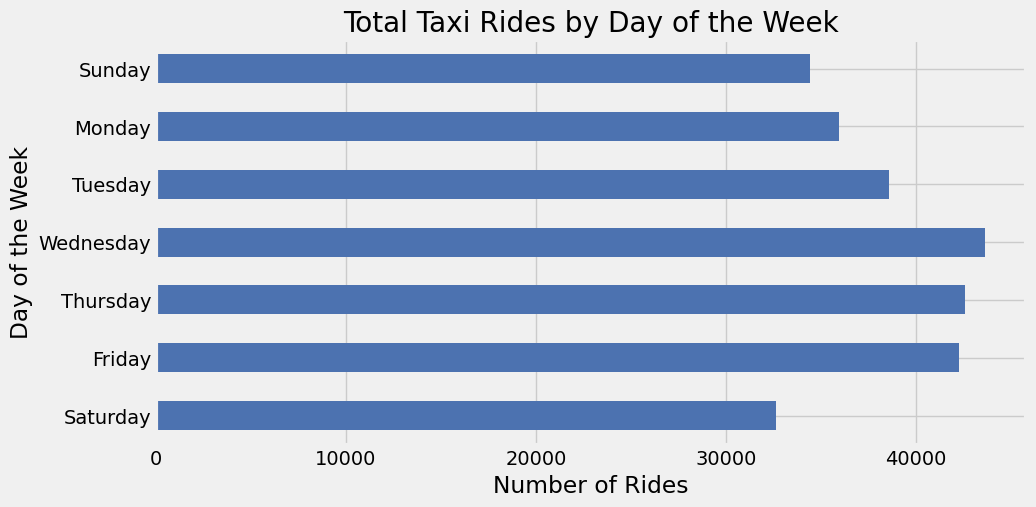

In [28]:
day_mapping = {
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 
    3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'
}

day_counts = df_balanced['Pickup_DayoftheWeek'].map(day_mapping).value_counts()
ordered_days = [
    'Sunday', 'Monday', 'Tuesday', 'Wednesday', 
    'Thursday', 'Friday', 'Saturday'
]

day_counts = day_counts.reindex(ordered_days)
ax = day_counts.plot(
    kind='barh', 
    title='Total Taxi Rides by Day of the Week', 
    figsize=(10, 5), 
    color='#4C72B0'  # A professional, muted blue
)

ax.set_xlabel('Number of Rides')
ax.set_ylabel('Day of the Week')
ax.invert_yaxis() 

plt.show()

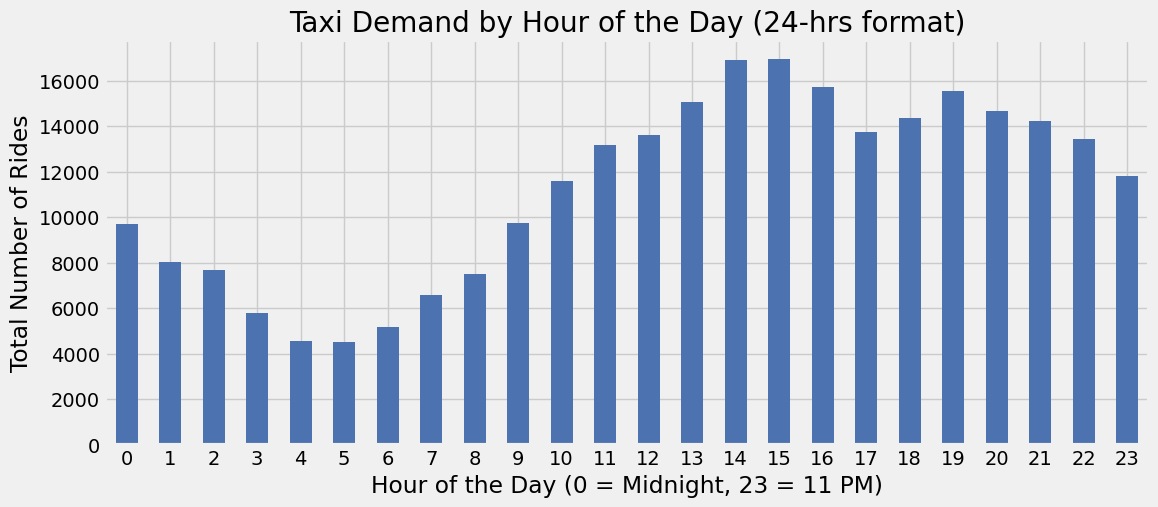

In [46]:
hourly_counts = df_balanced['Pickup_Hour'].value_counts().sort_index()

ax = hourly_counts.plot(
    kind='bar', 
    figsize=(12, 5), 
    title='Taxi Demand by Hour of the Day (24-hrs format)', 
    color='#4C72B0'  
)

ax.set_xlabel('Hour of the Day (0 = Midnight, 23 = 11 PM)')
ax.set_ylabel('Total Number of Rides')

plt.xticks(rotation=0)
plt.show()

#### Multivariate Analysis

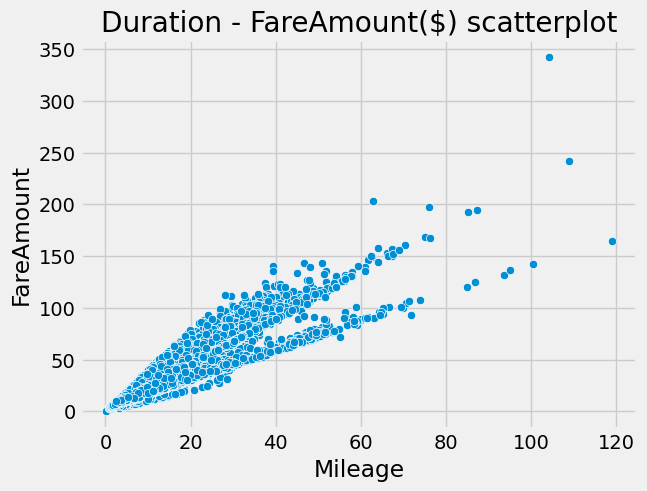

In [42]:
sns.scatterplot(x='Mileage', y='FareAmount', data=df_balanced)
plt.title('Duration - FareAmount($) scatterplot')
plt.show()

#### Determining Correlation between the transaction variables

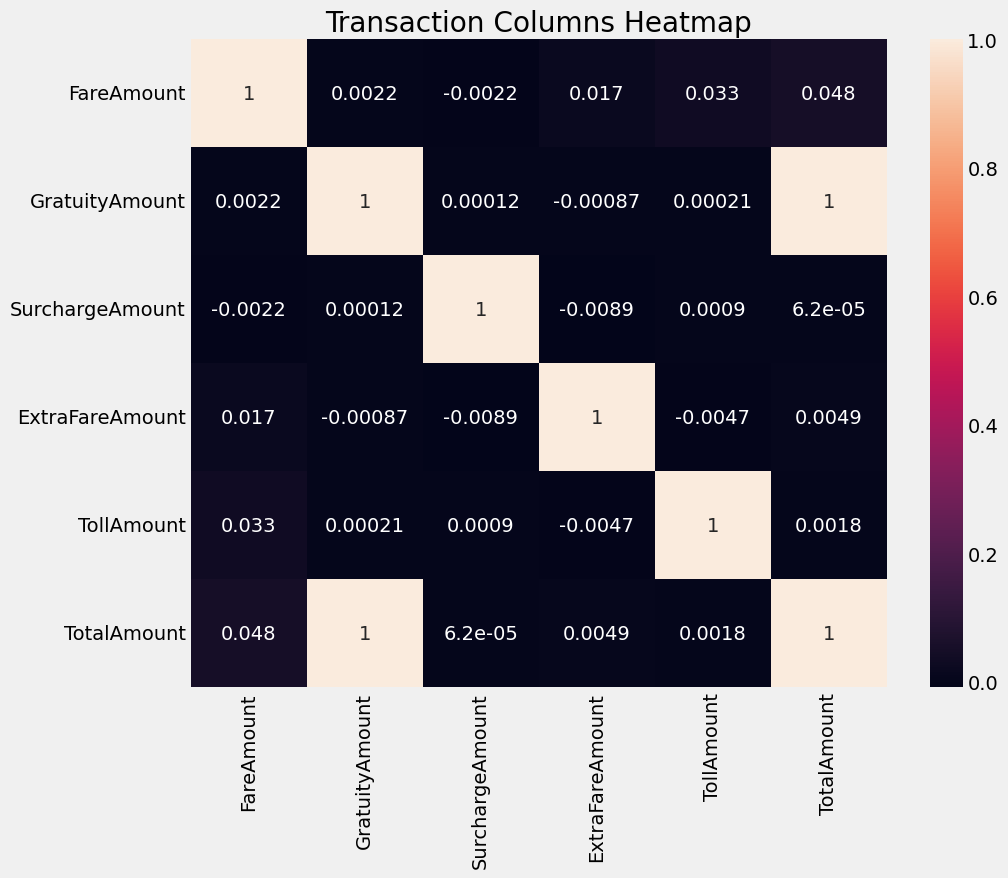

In [45]:
list_of_cols = ['FareAmount', 'GratuityAmount', 'SurchargeAmount',
                'ExtraFareAmount', 'TollAmount', 'TotalAmount']

df_corr = df_balanced[list_of_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True)
plt.title('Transaction Columns Heatmap')
plt.show()

GratuityAmount and TotalAmount has a *suspiciously high correlation value*. There's a high indication of Data Leakage if both will be used. The `GratuityAmount` column will be removed. Furthermore, SurchargeAmount, ExtraFareAmount, TollAmount, and TotalAmount would be dropped to avoid the mentioned issue.

In [51]:
df_balanced = df_balanced.drop(['GratuityAmount', 'SurchargeAmount',
                                'ExtraFareAmount', 'TollAmount', 'TotalAmount'], axis=1)

In [53]:
df_balanced.columns

Index(['ProviderName', 'FareAmount', 'OriginLatitude', 'OriginLongitude',
       'DestinationLatitude', 'DestinationLongitude', 'Mileage', 'Duration',
       'Pickup_Hour', 'Pickup_DayoftheWeek'],
      dtype='str')


## <span style="color: Orange;"> IV. Feature Importance </span>

I'll be utilizing XGBoost for now as it has less complexity and provides more precision compared to Random Forest. Furthermore, as the location columns (such as Latitude and longitude) are difficult to be interpret when using standard ML models (as coordinates are 3D), that is why the mentioned columns will be dropped.

In [56]:
df_balanced = df_balanced.drop(['OriginLatitude', 'OriginLongitude',
                                'DestinationLatitude', 'DestinationLongitude'], axis=1)

I'll be adapting the previous objective of the original project, which is to [1] predict the exact cost of the ride (`FareAmount`) and [2] predict which taxi provider is driving the passenger (`ProviderName`). Thus, dual-pipeline would be employed.

--- PIPELINE A: FARE PREDICTION ---


<Figure size 1000x500 with 0 Axes>

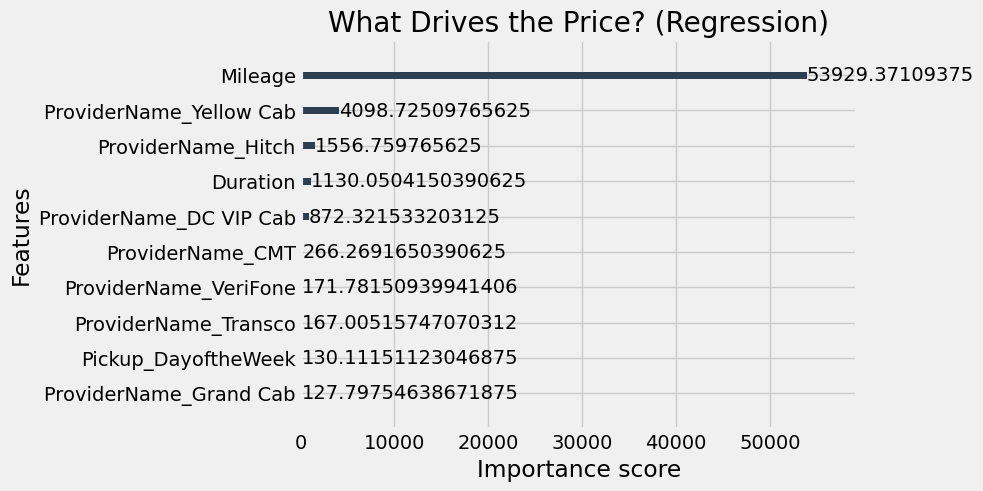

In [59]:
print("--- PIPELINE A: FARE PREDICTION ---")

X_price = df_balanced.drop(columns=['FareAmount'])
y_price = df_balanced['FareAmount']

# Convert text (ProviderName) into numbers
X_price_encoded = pd.get_dummies(X_price, columns=['ProviderName'], drop_first=True)

# Train the Regression Model
xgb_regressor = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_regressor.fit(X_price_encoded, y_price)

plt.figure(figsize=(10, 5))
xgb.plot_importance(
    xgb_regressor, 
    importance_type='gain', 
    max_num_features=10, 
    title='What Drives the Price? (Regression)',
    color='#2C3E50'
)
plt.show()

**Key points observed from the above picture:**  
- With the 'leaky' variables removed and classes for `ProviderName` is balanced, Feature Importance is now trustworthy because the model isn't 'cheating.' The absolute dominance of `Mileage` proves that my model is running well, as meter runs on distance. Because any indicative price of the trip were removed (columns such as TotalAmount, etc.), the model was forced to use the physical distance as its primary anchor for calculating the fare.
- With the `ProviderName` having the same amount of data for each instances, there's a big difference between the Yellow Cab rides and Transco rides. The model decided that company identity affects pricing. This likely indicates that Yellow Cab may have a drastically different pricing structure than the other companies, or other relevant factors.
- `Duration` sits in the middle of the pack. This can tell us a very clear story about the city traffic. While being stuck in a traffic jam does increase the fare, it does not impact the final price nearly as much as the physical distance driven.
- Features such as the `DayoftheWeek` are sitting the very bottom. This might indicate that while weekdays might have more rides, the actual cost per mile isn't affected directly.



--- PIPELINE B: PROVIDER PREDICTION ---


<Figure size 1000x500 with 0 Axes>

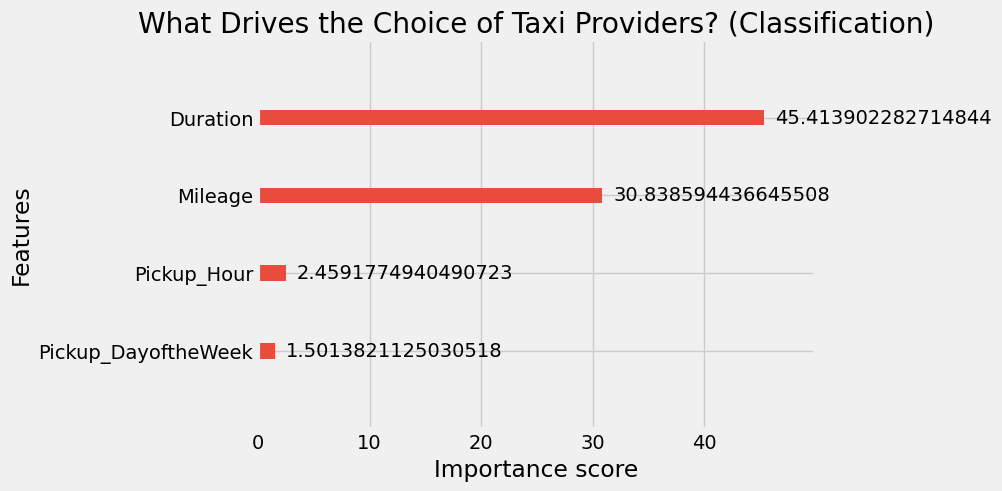

In [61]:
print("\n--- PIPELINE B: PROVIDER PREDICTION ---")

# CRITICAL: FareAmount is dropped here to prevent data leakage!
X_provider = df_balanced.drop(columns=['ProviderName', 'FareAmount'])
y_provider = df_balanced['ProviderName']

# Convert the Target text into numbers (e.g., Yellow Cab = 0, CMT = 1)
label_encoder = LabelEncoder()
y_provider_encoded = label_encoder.fit_transform(y_provider)

# Training the Classification Model
# We use XGBClassifier instead of Regressor!
xgb_classifier = xgb.XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1)
xgb_classifier.fit(X_provider, y_provider_encoded)

plt.figure(figsize=(10, 5))
xgb.plot_importance(
    xgb_classifier, 
    importance_type='gain', 
    max_num_features=10, 
    title='What Drives the Choice of Taxi Providers? (Classification)',
    color='#E74C3C'
)
plt.show()

**Key points observed from the above picture:**  
- My Dual-Pipeline architecture revealed that while `Distance` strictly dictates the cost of a ride, the nature of the traffic (`Duration` vs. `Distance`) is the primary driver for which taxi company fulfills the trip.
- Compared to the Pipeline A, `Duration` can heavily influence the prediction of taxi providers. This might indicate being stuck in heavy city traffic in a ride with high duration but low mileage, or fast highway driving of a ride with high duration but low mileage.
- The bottom two features indicates that each single provider is working 24/7. Because they operate on roughly the same schedule, knowing the time of the day doesn't help the model guess the company very much.

## <span style="color: Orange;"> V. Model Evaluation </span>

For predicting the exact dollar amounts, I'll use Root Mean Squared Error (RMSE).

In [ ]:
X_price = df_balanced.drop(columns=['FareAmount']).copy()
y_price = df_balanced['FareAmount']

X_price['ProviderName'] = X_price['ProviderName'].astype('category')

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_price, y_price, test_size=0.20, random_state=42
)

# Encoding
X_train_A_encoded = pd.get_dummies(X_train_A, columns=['ProviderName'], drop_first=True)
X_test_A_encoded = pd.get_dummies(X_test_A, columns=['ProviderName'], drop_first=True)

# Aligning the columns Prevents crashes if the train/test splits have different providers)
X_train_A_encoded, X_test_A_encoded = X_train_A_encoded.align(
    X_test_A_encoded, join='left', axis=1, fill_value=0
)

# Train the model ONLY on the 80% training data
xgb_regressor_eval = xgb.XGBRegressor(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1,
    enable_categorical=True  
)

xgb_regressor_eval.fit(X_train_A, y_train_A)

--- EVALUATING PIPELINE A (PRICE) ---


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [69]:
print("--- EVALUATING PIPELINE A (PRICE) ---")

predictions_A = xgb_regressor_eval.predict(X_test_A)

rmse = root_mean_squared_error(y_test_A, predictions_A)
mae = mean_absolute_error(y_test_A, predictions_A)

print(f"Average Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

--- EVALUATING PIPELINE A (PRICE) ---
Average Error (MAE): $0.88
Root Mean Squared Error (RMSE): $1.89


**Key insights from the evaluation:**  
For Model Pipeline A, the margin of error is 88 cent. However, the RMSE is a dollar higher than MAE, which might indicate that most of the predictions are accurate (only off by pennies), but occassionally, the model gets a ride wrong (i.e. off by $4 or $5).

---

In [73]:
# CRITICAL: We drop FareAmount so the model can't cheat!
X_provider = df_balanced.drop(columns=['ProviderName', 'FareAmount']).copy()
y_provider = df_balanced['ProviderName']

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_provider, y_provider, test_size=0.20, random_state=42
)

# ENCODE THE TARGET 
# XGBoost classification needs the target labels to be numbers (0, 1, 2...)
label_encoder = LabelEncoder()

# Fit the rules ONLY on the training data, then transform both
y_train_B_encoded = label_encoder.fit_transform(y_train_B)
y_test_B_encoded = label_encoder.transform(y_test_B)

# Training the Classification Model
xgb_classifier_eval = xgb.XGBClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1
)

xgb_classifier_eval.fit(X_train_B, y_train_B_encoded)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [74]:
print("--- EVALUATING PIPELINE B (TAXI PROVIDER PREDICTOR) ---")
predictions_B = xgb_classifier_eval.predict(X_test_B)
accuracy = accuracy_score(y_test_B_encoded, predictions_B)

print(f"\nOverall Accuracy: {accuracy * 100:.2f}%")
print("-" * 50)
print("Detailed Classification Report:")

# Translate the integer predictions back to the actual company names for the report
print(classification_report(y_test_B_encoded, predictions_B, target_names=label_encoder.classes_))

--- EVALUATING PIPELINE B (TAXI PROVIDER PREDICTOR) ---

Overall Accuracy: 41.78%
--------------------------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

     Bay Cab       0.42      0.49      0.45      5943
         CMT       0.47      0.56      0.51      6027
  DC VIP Cab       0.50      0.21      0.29      5962
   Grand Cab       0.42      0.61      0.50      6037
       Hitch       0.44      0.50      0.47      6017
     Transco       0.40      0.44      0.42      5983
         UVC       0.33      0.08      0.13      5912
    VeriFone       0.30      0.39      0.34      6061
  Yellow Cab       0.49      0.48      0.48      6058

    accuracy                           0.42     54000
   macro avg       0.42      0.42      0.40     54000
weighted avg       0.42      0.42      0.40     54000



**Key insights from the evaluation:**
- Pipeline B successfully decoded taxi providers operating patterns. Rather than driving identical routes, companies like CMT exhibit highly predictable trip lengths, allowing the algorithm to classify their rides with over 50% accuracy. The recall is somehow high in some classes, such as Grand Cab indicating that the model successfully found 61% of the actual Grand Cab rides. 
- In comparison, if we look at the UVC, the recall is astonishingly low at 8%, indicating that the model almost never guesses it's UVC. Companies like UVC operate essentially as 'ghosts' in the data, absorbing random trips without a specialized niche. Their trip times and distances might look exactly like everyone else's, making them mathematiclaly invisible to the algorithm.

## <span style="color:Orange;"> VI. Deep Learning </span>

This segment will be edited in the near future...

## <span style="color:Orange;"> VII. Results and Discussion </span>

##### **Pipeline A: Taxi Fare Prediction**

In [ ]:
print("--- PIPELINE A: SAMPLE PREDICTIONS ---")

results_df = X_test_A.copy()

# Adding the "Actual" and "Predicted" columns
results_df['Actual_Fare'] = y_test_A
results_df['Predicted_Fare'] = predictions_A.round(2)

# Calculating exactly how much the model was off by
results_df['Dollar_Error'] = (results_df['Predicted_Fare'] - results_df['Actual_Fare']).round(2)

# Rearranging the columns so the money is easy to see at the front
cols = ['ProviderName', 'Mileage', 'Duration', 'Actual_Fare', 'Predicted_Fare', 'Dollar_Error']
results_df = results_df[cols]

display(results_df.head(10))

--- PIPELINE A: SAMPLE PREDICTIONS ---


,ProviderName,Mileage,Duration,Actual_Fare,Predicted_Fare,Dollar_Error
3698037,Yellow Cab,7.13,18.0,15.67,16.240000,0.57
5182494,UVC,4.70,11.0,14.32,14.020000,-0.30
3363948,CMT,5.00,14.0,15.67,15.540000,-0.13
5778084,Hitch,3.00,15.0,11.08,11.470000,0.39
452988,Bay Cab,4.74,808.0,16.21,15.450000,-0.76
5246062,Transco,10.02,28.0,30.52,28.209999,-2.31
454979,CMT,3.00,10.0,10.54,10.450000,-0.09
3711645,Yellow Cab,6.37,15.0,13.51,15.270000,1.76
2535683,VeriFone,4.60,12.0,13.78,14.100000,0.32
40652,CMT,2.00,7.0,7.57,7.570000,0.00


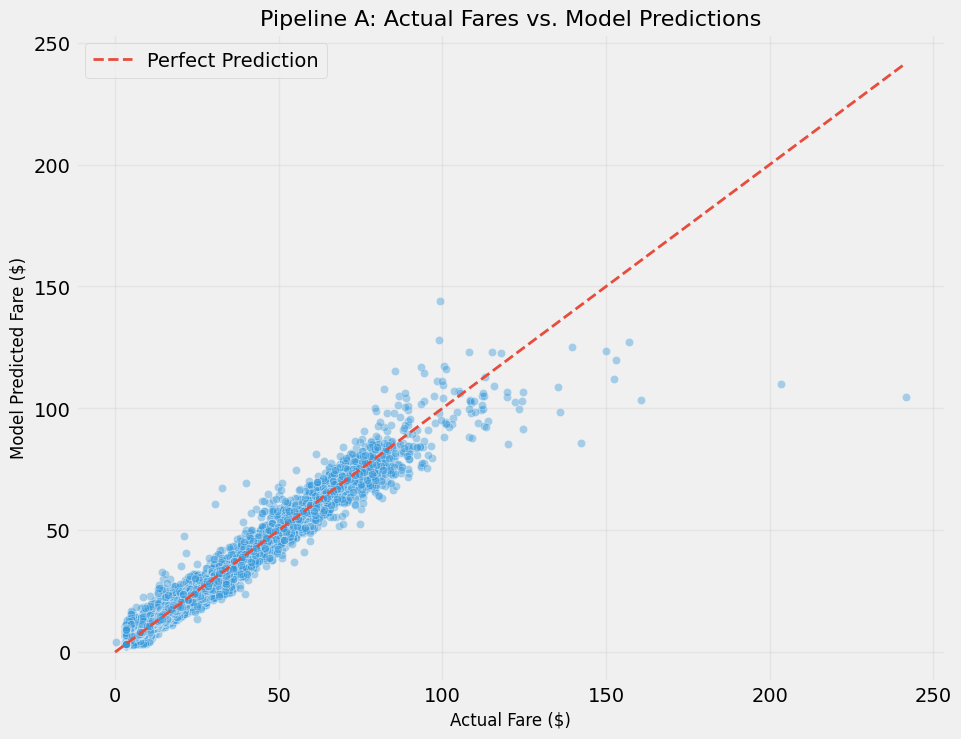

In [76]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    x=y_test_A, 
    y=predictions_A, 
    alpha=0.4,      
    color='#3498DB' 
)

# Draw the "Perfect Prediction" Line
# If the model guessed $15 and the actual was $15, the dot lands exactly on this line.
max_fare = max(y_test_A.max(), predictions_A.max())
plt.plot(
    [0, max_fare], [0, max_fare], 
    color='#E74C3C', linestyle='--', linewidth=2, 
    label='Perfect Prediction'
)

plt.title('Pipeline A: Actual Fares vs. Model Predictions', fontsize=16)
plt.xlabel('Actual Fare ($)', fontsize=12)
plt.ylabel('Model Predicted Fare ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##### **Pipeline B: Taxi Provider Classification**

In [77]:
print("--- PIPELINE B: SAMPLE PREDICTIONS ---")

# Translating the numbered answers back into real company names
actual_names = label_encoder.inverse_transform(y_test_B_encoded)
predicted_names = label_encoder.inverse_transform(predictions_B)

results_df_B = X_test_B.copy()

# Adding the Actual and Predicted columns
results_df_B['Actual_Company'] = actual_names
results_df_B['Predicted_Company'] = predicted_names

# Create a "Grader" column (True if it got it right, False if it missed)
results_df_B['Correct_Guess'] = results_df_B['Actual_Company'] == results_df_B['Predicted_Company']

# Rearrange columns to put the answers up front
cols = ['Actual_Company', 'Predicted_Company', 'Correct_Guess', 'Mileage', 'Duration', 'Pickup_Hour']
results_df_B = results_df_B[cols]

display(results_df_B.head(10))

--- PIPELINE B: SAMPLE PREDICTIONS ---


,Actual_Company,Predicted_Company,Correct_Guess,Mileage,Duration,Pickup_Hour
3698037,Yellow Cab,VeriFone,False,7.13,18.0,0
5182494,UVC,UVC,True,4.70,11.0,23
3363948,CMT,Hitch,False,5.00,14.0,11
5778084,Hitch,CMT,False,3.00,15.0,1
452988,Bay Cab,Bay Cab,True,4.74,808.0,18
5246062,Transco,Hitch,False,10.02,28.0,22
454979,CMT,CMT,True,3.00,10.0,19
3711645,Yellow Cab,Transco,False,6.37,15.0,11
2535683,VeriFone,DC VIP Cab,False,4.60,12.0,22
40652,CMT,CMT,True,2.00,7.0,21


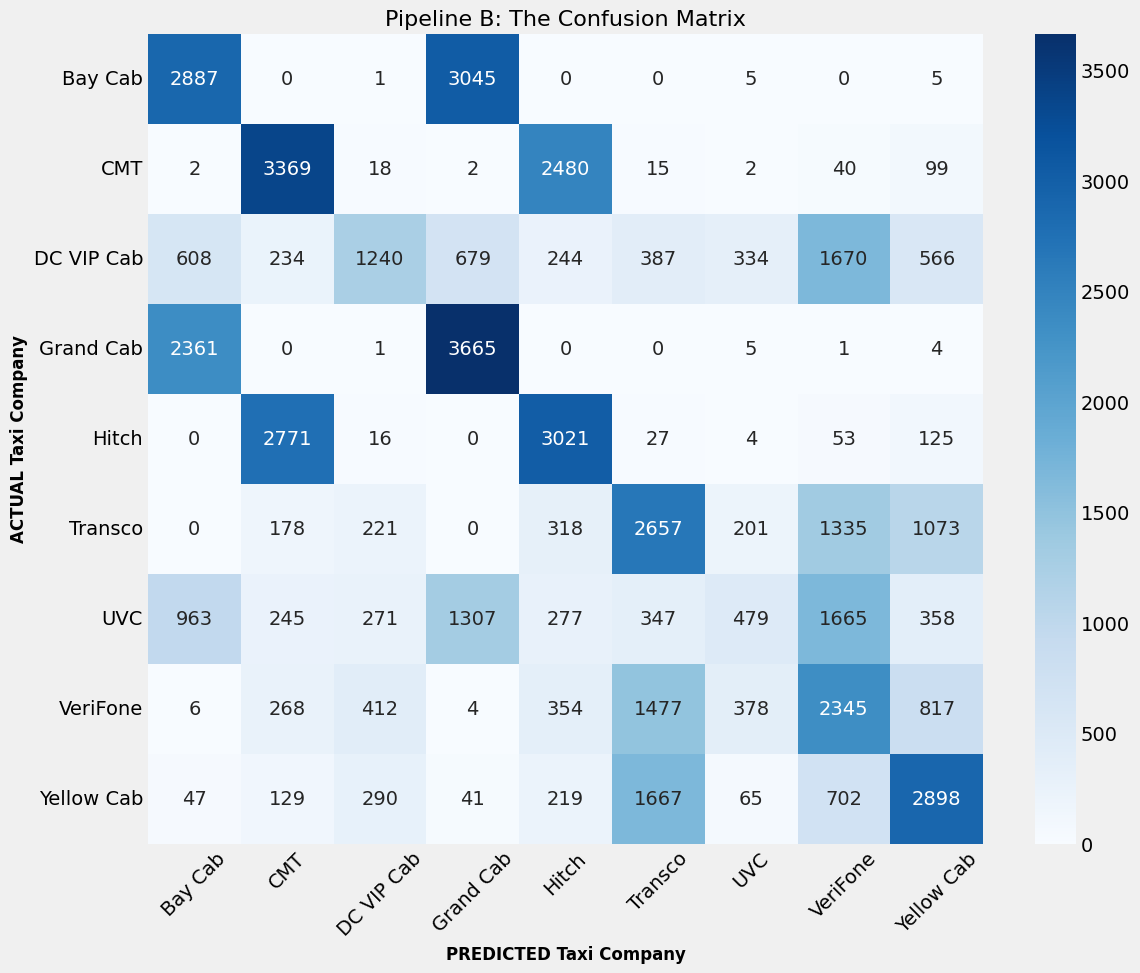

In [79]:
# Generating the raw matrix of numbers
cm = confusion_matrix(y_test_B_encoded, predictions_B)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, 
    annot=True,        
    fmt='d',       
    cmap='Blues',      
    xticklabels=label_encoder.classes_, 
    yticklabels=label_encoder.classes_  
)

plt.title('Pipeline B: The Confusion Matrix', fontsize=16)
plt.ylabel('ACTUAL Taxi Company', fontsize=12, fontweight='bold')
plt.xlabel('PREDICTED Taxi Company', fontsize=12, fontweight='bold')
plt.xticks(rotation=45) # Tilt the names so they don't overlap
plt.show()

<p> <br>
    As what we can see from the example predictiion results above, the regression prediction (pipeline A) is highly accurate with the margin of absolute error values within $3. However, since the accuracy is 42% in the classification (pipeline B), the model fairly identifies correct taxi providers, though few classes had bad prediction such as UVC. The Confusion Matrix revealed operational overlaps in the market. For instance, if we'll view the above figure, based purely on trip duration and mileage, Bay Cab rides are functionally identical to Grand Cab rides that the algorithm is actually more likely to confuse the two than tell them apart.
    <br>
    <br>
 </p>

 ---

## <span style="color: Orange;"> VIII. Conclusion </span>

TBA

<p align='center'> <br> ▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄▀▄  </p>